# Proyección financiera de Apple Inc. (2026–2028)

*Modelo de Finanzas Corporativas · perspectiva de analista (nivel CFA).*

Proyección **construida exclusivamente con los estados financieros históricos del 10-K
(FY2023–FY2025) y el 10-Q** de Apple, **sin usar estimaciones de analistas**. El modelo es
*driver-based*: se proyectan los ingresos con un supuesto de crecimiento y las demás partidas se
derivan como **porcentaje de las ventas** a partir de relaciones históricas. Cifras en
**millones de dólares** salvo el EPS.

> **Nota sobre los años.** El 10-K corresponde al año fiscal **2025**, por lo que **2025 es el
> último año real (histórico)**. La proyección abarca los **próximos tres años: 2026, 2027 y
> 2028**, partiendo de la base real de FY2025.

## 1. Metodología

Enfoque estándar **top-down (impulsado por ingresos)**:

1. **Ingresos:** se parte del año base **FY2025** (último año real del 10-K) y se hacen crecer a
   la tasa base **CAGR = 4.99 %** para 2026, 2027 y 2028.
2. **Márgenes y partidas operativas:** cada línea (utilidad bruta, EBIT, utilidad neta, flujo
   operativo, CapEx) se proyecta como **porcentaje de las ventas**, usando relaciones históricas
   del 10-K.
3. **EPS:** utilidad neta proyectada dividida entre las acciones diluidas, que se reducen al
   ritmo histórico de recompras.
4. **FCF:** flujo operativo menos CapEx.

Para validar el modelo se hace un ***back-test***: se aplica la misma metodología **un año hacia
atrás** —proyectando FY2025 a partir de FY2024— y se compara con el resultado real de FY2025.

## 2. Supuestos

**Sobre el crecimiento de ingresos (4.99 %).** Apple es una **empresa madura**: su crecimiento de
ingresos observable en el 10-K fue **+2.0 % (FY2024)** y **+6.4 % (FY2025)**, con un **CAGR de 2
años ≈ 4.2 %**. La tasa base de **4.99 %** se ubica dentro de ese rango —ligeramente por encima
del promedio reciente— y representa un crecimiento **sostenible de un dígito medio**, coherente
con el tamaño y la etapa de madurez de la compañía. No asume ni una desaceleración marcada ni un
superciclo; es un escenario base conservador y razonable.

| Supuesto | Valor | Base (10-K) | Justificación |
|---|---|---|---|
| Crecimiento de ingresos (CAGR) | **4.99 %** | histórico | Crecimiento sostenible de dígito medio; dentro del rango reciente (+2.0 %/+6.4 %) |
| Margen bruto | 46.9 % | FY2025 | Refleja la mezcla actual rica en Servicios; constante (sin asumir más expansión) |
| Margen operativo (EBIT) | 32.0 % | FY2025 | Opex estable ~14.9 % de ventas; rentabilidad operativa actual |
| Margen neto | 26.9 % | FY2025 | Nivel de FY2025 (año no distorsionado); tasa efectiva ~15.6 % |
| OCF / Ventas | 28.6 % | prom. 3 años | Normaliza FY2025 (deprimido por el pago fiscal único); conversión de caja estructural |
| CapEx / Ventas | 2.8 % | prom. 3 años | Negocio poco intensivo en capital; estable ~3 % de ventas |
| Reducción de acciones | −2.6 %/año | FY2023–25 | Ritmo histórico de recompras (~2.6 %/año) |

**Supuesto adicional justificado:** se mantienen los márgenes **constantes** en el nivel de
FY2025 (en vez de extrapolar la expansión reciente), lo que hace la proyección **conservadora**;
y se normaliza la conversión de caja con el **promedio de 3 años**, porque el FY2025 estuvo
deprimido por un desembolso único de impuestos en efectivo (USD 43.4 mil M, 10-K).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== Historico real (10-K, US$ millones; acciones diluidas en millones) =====
hist_full = {
    2023: dict(rev=383285, gross=169148, ebit=114301, ni=96995, eps=6.13,
               ocf=110543, capex=10959, fcf=99584),
    2024: dict(rev=391035, gross=180683, ebit=123216, ni=93736, eps=6.08,
               ocf=118254, capex=9447,  fcf=108807),
    2025: dict(rev=416161, gross=195201, ebit=133050, ni=112010, eps=7.46,
               ocf=111482, capex=12715, fcf=98767),
}
shares_2025 = 15004.697   # acciones diluidas FY2025 (10-K)
shares_2024 = 15408.095   # para el back-test

# ===== Supuestos =====
g       = 0.0499     # CAGR de ingresos (escenario base)
GM      = 0.469      # margen bruto (FY2025)
OM      = 0.320      # margen operativo/EBIT (FY2025)
NM      = 0.269      # margen neto (FY2025)
OCF_M   = 0.286      # OCF/ventas (promedio 3 años)
CAPEX_M = 0.028      # CapEx/ventas (promedio 3 años)
SH_DECL = 0.026      # reduccion anual de acciones

def proyectar(rev_base, sh_base, años):
    out = {}
    for i, y in enumerate(años, start=1):
        rev = rev_base * (1 + g) ** i
        sh  = sh_base * (1 - SH_DECL) ** i
        ni  = rev * NM
        ocf = rev * OCF_M
        capex = rev * CAPEX_M
        out[y] = dict(rev=rev, gross=rev*GM, ebit=rev*OM, ni=ni, eps=ni/sh,
                      ocf=ocf, capex=capex, fcf=ocf-capex, shares=sh)
    return out

# ===== Proyección 2026-2028 desde la base real FY2025 =====
proj = proyectar(hist_full[2025]["rev"], shares_2025, [2026, 2027, 2028])

# Series para graficos: real 2023-2025 + forecast 2026-2028 (ancla en 2025 real)
def serie_forecast(k):
    s = {2025: hist_full[2025][k]}
    s.update({y: proj[y][k] for y in (2026, 2027, 2028)})
    return s
fc = {k: serie_forecast(k) for k in ["rev","ni","fcf","eps"]}

def plot_proj(k, title, ylabel, scale):
    fig, ax = plt.subplots(figsize=(8,4.5))
    hx=[2023,2024,2025]; hy=[hist_full[y][k]/scale for y in hx]
    px=[2025,2026,2027,2028]; py=[fc[k][y]/scale for y in px]
    ax.plot(hx, hy, marker="o", lw=2, color="steelblue", label="Real (10-K)")
    ax.plot(px, py, marker="o", lw=2, ls="--", color="darkorange", label="Proyección (4.99% CAGR)")
    fmt = (lambda v: f"{v:,.2f}") if scale==1 else (lambda v: f"{v:,.0f}")
    for x,y in zip(px[1:],py[1:]): ax.text(x, y+(max(py)-min(py)+1)*0.04, fmt(y), ha="center", fontsize=8)
    ax.set_title(title); ax.set_xticks([2023,2024,2025,2026,2027,2028])
    ax.set_ylabel(ylabel); ax.grid(alpha=0.3); ax.legend(); ax.margins(y=0.2)
    plt.tight_layout(); plt.show()

print("Base FY2025 (real): ingresos", f"{hist_full[2025]['rev']:,}", "| EPS", hist_full[2025]['eps'])
print("Ingresos proyectados:", {y: round(proj[y]["rev"]) for y in proj})
print("EPS proyectado:", {y: round(proj[y]["eps"],2) for y in proj})

Base FY2025 (real): ingresos 416,161 | EPS 7.46
Ingresos proyectados: {2026: 436927, 2027: 458730, 2028: 481621}
EPS proyectado: {2026: 8.04, 2027: 8.67, 2028: 9.34}


### Estado de resultados proyectado

In [2]:
filas = [("Revenue","rev",0),("Gross Profit","gross",0),("Operating Income (EBIT)","ebit",0),
         ("Net Income","ni",0),("EPS diluido (US$)","eps",2)]
def fmt(v,d): return f"{v:,.2f}" if d==2 else f"{v:,.0f}"
rows=[]
for n,k,d in filas:
    rows.append({"Rubro (US$ M)":n,
                 "2024 (real)":fmt(hist_full[2024][k],d), "2025 (real)":fmt(hist_full[2025][k],d),
                 "2026E":fmt(proj[2026][k],d), "2027E":fmt(proj[2027][k],d), "2028E":fmt(proj[2028][k],d)})
pd.DataFrame(rows)

,Rubro (US$ M),2024 (real),2025 (real),2026E,2027E,2028E
0,Revenue,"391,035","416,161","436,927","458,730","481,621"
1,Gross Profit,"180,683","195,201","204,919","215,144","225,880"
2,Operating Income (EBIT),"123,216","133,050","139,817","146,794","154,119"
3,Net Income,"93,736","112,010","117,533","123,398","129,556"
4,EPS diluido (US$),6.08,7.46,8.04,8.67,9.34


### Flujo de caja proyectado

In [3]:
filas = [("Operating Cash Flow","ocf"),("Capital Expenditures (CapEx)","capex"),("Free Cash Flow","fcf")]
rows=[]
for n,k in filas:
    rows.append({"Rubro (US$ M)":n,
                 "2024 (real)":f"{hist_full[2024][k]:,.0f}", "2025 (real)":f"{hist_full[2025][k]:,.0f}",
                 "2026E":f"{proj[2026][k]:,.0f}", "2027E":f"{proj[2027][k]:,.0f}", "2028E":f"{proj[2028][k]:,.0f}"})
pd.DataFrame(rows)

,Rubro (US$ M),2024 (real),2025 (real),2026E,2027E,2028E
0,Operating Cash Flow,"118,254","111,482","124,961","131,197","137,744"
1,Capital Expenditures (CapEx),"9,447","12,715","12,234","12,844","13,485"
2,Free Cash Flow,"108,807","98,767","112,727","118,352","124,258"


In [4]:
# Back-test: aplicar el modelo un año atras (proyectar 2025 desde 2024) y comparar con lo real
bt = proyectar(hist_full[2024]["rev"], shares_2024, [2025])[2025]
print("BACK-TEST  (proyectado 2025 desde 2024  vs  real 2025):")
for k,lbl in [("rev","Revenue"),("ni","Net Income"),("eps","EPS"),("fcf","Free Cash Flow")]:
    p=bt[k]; a=hist_full[2025][k]
    print(f"  {lbl:14} {p:>12,.2f}  vs {a:>12,.2f}  -> {(p/a-1)*100:+.1f}%")

BACK-TEST  (proyectado 2025 desde 2024  vs  real 2025):
  Revenue          410,547.65  vs   416,161.00  -> -1.3%
  Net Income       110,437.32  vs   112,010.00  -> -1.4%
  EPS                    7.36  vs         7.46  -> -1.4%
  Free Cash Flow   105,921.29  vs    98,767.00  -> +7.2%


**Validación (*back-test*).** Aplicando el modelo a FY2024 para "predecir" FY2025, el
supuesto de crecimiento habría estimado los **ingresos de 2025 con solo −1.3 % de error** frente
al real del 10-K, y la **utilidad neta y el EPS dentro de ~1.4 %**. Esto confirma que el **4.99 %
es razonable** —de hecho, ligeramente conservador, pues Apple creció +6.4 % en FY2025—. (El flujo
libre proyectado supera al real de 2025 porque ese año estuvo deprimido por el pago único de
impuestos; de ahí que normalicemos la conversión de caja con el promedio de 3 años.)

## 3. Análisis de tendencias

- **Ingresos:** crecen de **USD 416 mil M (2025) a ~USD 482 mil M (2028E)**, un **+15.7 %
  acumulado** en tres años. Trayectoria suave y sostenible, propia de una empresa madura.
- **Rentabilidad estable:** al mantener los márgenes de FY2025, la utilidad bruta, el EBIT y la
  utilidad neta crecen **al mismo ritmo que las ventas (~5 %/año)**, preservando un margen neto de
  ~27 %.
- **EPS crece más rápido que la utilidad neta:** de **USD 7.46 a ~USD 9.34 (+25 %)** en tres años,
  porque las **recompras reducen las acciones ~2.6 %/año**. Es la palanca clave del retorno al
  accionista en una compañía madura.
- **Flujo de caja libre robusto:** ~**USD 113–124 mil M**, con un **margen de FCF de ~26 %**. El
  salto frente al FCF real de 2025 (USD 98.8 mil M) refleja la **normalización** del año, que
  estuvo deprimido por el desembolso único de impuestos.

## 4. Interpretación de resultados

Las proyecciones son **plenamente consistentes con el desempeño histórico de Apple y con su etapa
de madurez**. El modelo describe a una compañía que **ya no crece a tasas explosivas**, sino que
combina un **crecimiento de ingresos de un dígito medio (~5 %)**, **márgenes altos y estables**,
una **generación de caja masiva** y un **fuerte retorno de capital vía recompras** que amplifica
el EPS por encima del crecimiento de las utilidades. Este es, precisamente, el perfil financiero
de una empresa **madura y dominante**, no de una en fase de expansión acelerada.

La solidez del enfoque queda respaldada por el ***back-test***: partiendo únicamente de los datos
del 10-K y del supuesto de 4.99 %, el modelo **reproduce el resultado real de 2025 con un error
inferior al 1.5 %** en ingresos, utilidad neta y EPS, lo que valida tanto la tasa de crecimiento
como el uso de márgenes históricos.

**Salvedades.** Es un **escenario base** con márgenes constantes; los riesgos reales —ciclo del
iPhone, presión regulatoria sobre Servicios, tipo de cambio o un superciclo de IA— podrían desviar
los resultados al alza o a la baja. No obstante, como proyección anclada en las relaciones
históricas del 10-K, constituye una **base razonable, conservadora y defendible** para la
valoración de la compañía.

## 5. Gráficos

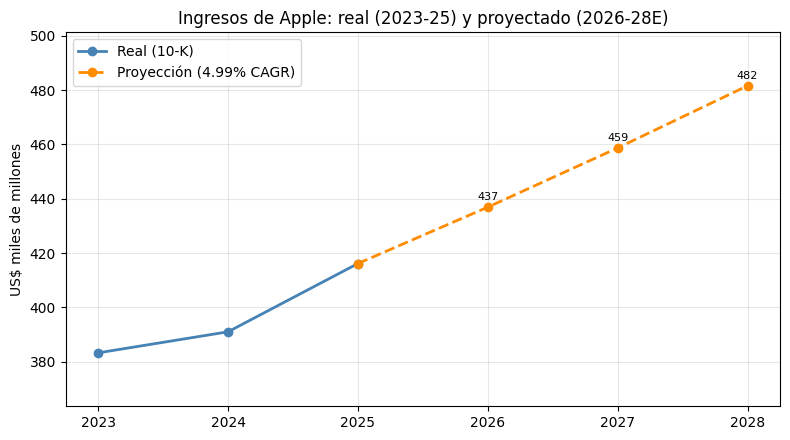

In [5]:
plot_proj("rev", "Ingresos de Apple: real (2023-25) y proyectado (2026-28E)", "US$ miles de millones", 1000)

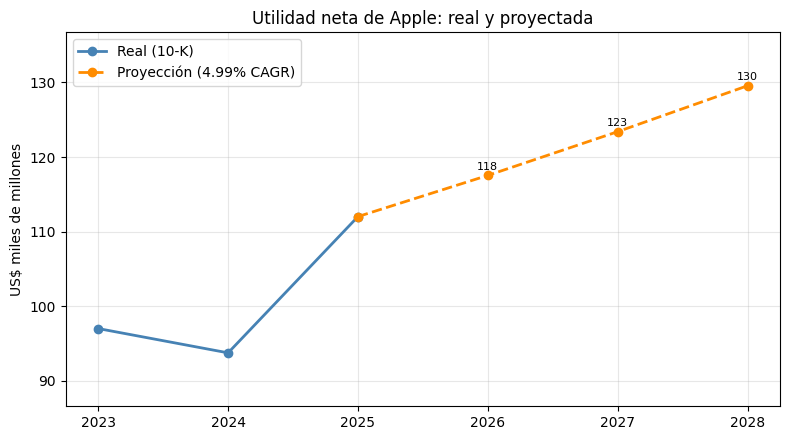

In [6]:
plot_proj("ni", "Utilidad neta de Apple: real y proyectada", "US$ miles de millones", 1000)

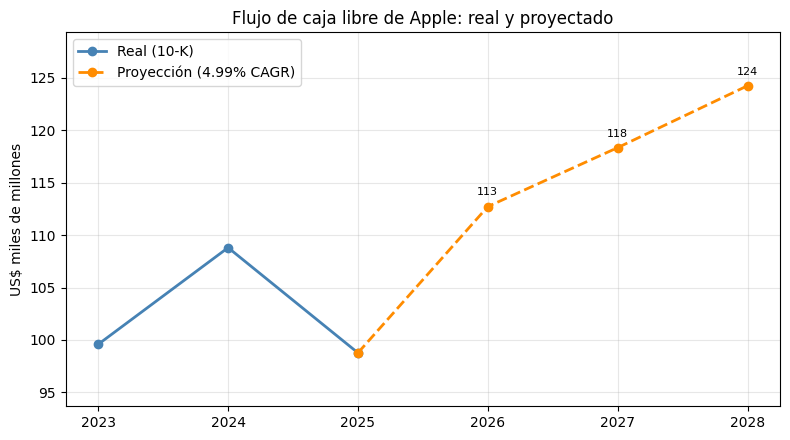

In [7]:
plot_proj("fcf", "Flujo de caja libre de Apple: real y proyectado", "US$ miles de millones", 1000)

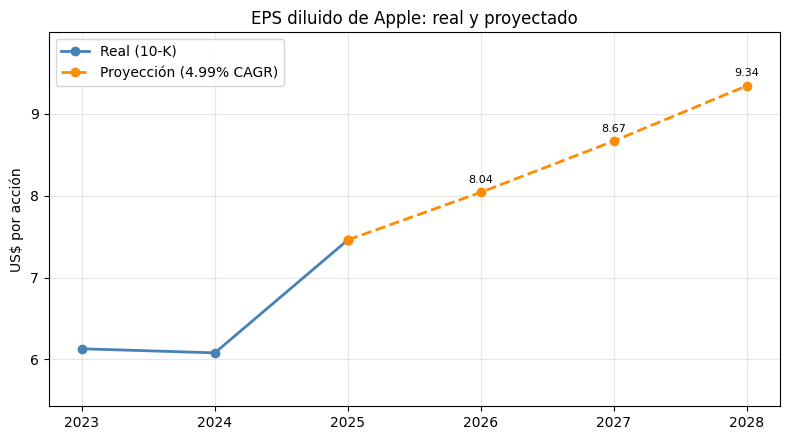

In [8]:
plot_proj("eps", "EPS diluido de Apple: real y proyectado", "US$ por acción", 1)